# Shallow Recurrent Decoders: Kolmogorov flow - Parametric

This notebook demonstrates the reconstruction of the Kolmogorov flow using a shallow recurrent decoder in parametric scenarios. The Kolmogorov flow is a classic problem in fluid dynamics, characterized by its periodic forcing and complex vortex structures. In this notebook, we will simulate the flow and visualize its evolution over time. The governing equations are the incompressible Navier-Stokes equations, which describe the motion of fluid substances.

SHRED is used in a multi parameter realisation context.

At first, let us solve the Kolmogorov flow problem. The following code snippet sets up the simulation parameters and runs the solver.

The viscosity will be varied (the data generation should take around 20/30 minutes to run). The results will be saved in a file named `kolmo2d.npz` for later use.

In [1]:
from utils import solve_kolmogorov_2d
import numpy as np
import os
from IPython.display import clear_output as clc

nu_values = np.logspace(np.log10(0.050), np.log10(0.060), num=20)

N = 64
path_data = 'kolmo2d.npz'

if os.path.exists(path_data):
    data = np.load(path_data)
    snaps = data['snaps']
    times = data['times']
    nu_values = data['nu_values']
    Reynolds = data['Reynolds']
else:
    snaps = []
    Reynolds = []

    for ii, _nu in enumerate(nu_values):

        print(f"Running simulation {ii+1}/{len(nu_values)} with viscosity nu={_nu:.5f}")

        # Run the solver
        times, _snaps, Re = solve_kolmogorov_2d(
            viscosity=_nu, 
            N=N, 
            t_max=200.0, 
            num_snapshots=500,
            dt = 0.05
        )
        snaps.append(_snaps.T)
        Reynolds.append(Re)

        clc()

    snaps = np.array(snaps)
    Reynolds = np.array(Reynolds)
    np.savez_compressed(path_data, snaps=snaps, times=times, nu_values=nu_values, Reynolds=Reynolds)

Let us visualize the results of the Kolmogorov flow simulation. The following code snippet iterates through the saved snapshots and generates plots of the vorticity field at different time instances.

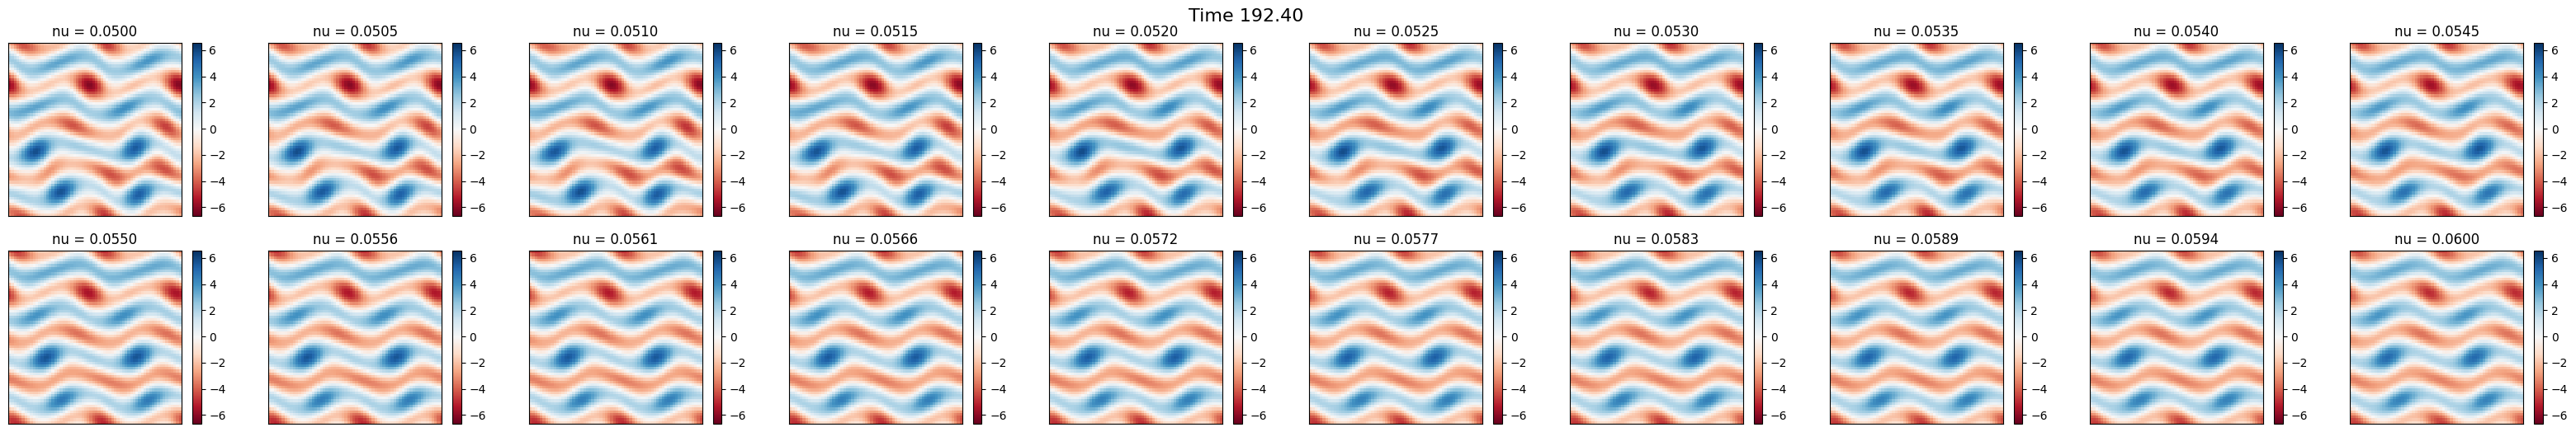

In [2]:
from IPython.display import clear_output as clc
from matplotlib import pyplot as plt
import numpy as np

clims = (snaps.min(), snaps.max())

nrows = 2
ncols = len(nu_values) // nrows + (len(nu_values) % nrows > 0)

for tt in range(0, len(times), 20):

    fig, axs = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
    axs = axs.flatten()  # Flatten the array of axes for easy iteration
    L = 2 * np.pi
    
    for ii, ax in enumerate(axs):
        if ii >= len(nu_values):
            ax.axis('off')  # Turn off axes for empty subplots
            continue
        omega_plot = snaps[ii, tt].reshape((N, N))
        t_plot = times[tt]

        im = ax.imshow(
            omega_plot, 
            extent=[0, L, 0, L], 
            origin='lower', 
            cmap='RdBu',
            vmin=clims[0], vmax=clims[1] # Fixed limits help track amplitude changes
        )
        ax.set_title(f"nu = {nu_values[ii]:.4f}")
        ax.set_xticks([])
        ax.set_yticks([])

        # Add a single colorbar for the whole figure
        cbar = fig.colorbar(im, ax=ax)

    plt.suptitle("Time " + f"{t_plot:.2f}", fontsize=16, y=0.95)
    plt.show()
    clc(wait=True)  # Clear the output for the next frame
    plt.close()

Let us split the parameters into train, test and valid

Train size: 15, Validation size: 2, Test size: 3


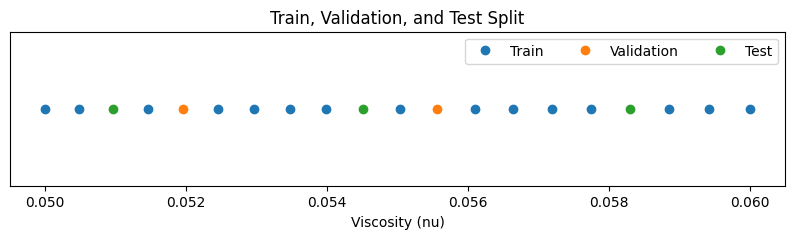

In [3]:
Nt = len(times)
assert snaps.shape[1] == Nt, "Mismatch in number of time snapshots"
Ns = snaps.shape[0]
Nh = snaps.shape[2]

from sklearn.model_selection import train_test_split
test_idx = np.arange(2, Ns, 7)  
train_valid_idx = np.setdiff1d(np.arange(Ns), test_idx)
valid_idx = np.setdiff1d(np.arange(4, Ns-2, 7), test_idx)  # ensure no overlap with test
train_idx = np.setdiff1d(train_valid_idx, valid_idx)

plt.figure(figsize=(10, 2))
plt.plot(nu_values[train_idx], np.zeros_like(train_idx), 'o', label='Train')
plt.plot(nu_values[valid_idx], np.zeros_like(valid_idx), 'o', label='Validation')
plt.plot(nu_values[test_idx], np.zeros_like(test_idx), 'o', label='Test')
plt.xlabel('Viscosity (nu)')
plt.title('Train, Validation, and Test Split')
plt.legend(ncols=3)
# plt.xscale('log')
plt.yticks([])  # Hide y-axis ticks since they are not meaningful here

prediction_time_cut = int(Nt * 0.9)
snapshots = {
    'train': snaps[train_idx][:, :prediction_time_cut],
    'valid': snaps[valid_idx][:, :prediction_time_cut],
    'test': snaps[test_idx]
}

Ns_sizes = {key: snapshots[key].shape[0] for key in snapshots.keys()}
Nt_sizes = {key: snapshots[key].shape[1] for key in snapshots.keys()}

print(f"Train size: {Ns_sizes['train']}, Validation size: {Ns_sizes['valid']}, Test size: {Ns_sizes['test']}")

## Data preparation
In this section, the SVD is performed to reduce the dimensionality of the data. The SVD is performed on the vorticity snapshots, and the resulting singular values and vectors are used to construct a low-dimensional representation of the flow. Then, measurements are generating by randomly sampling sensors in the domain.

Let us perform the randomized SVD

In [4]:
from sklearn.utils.extmath import randomized_svd
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

modes, singular_values, _ = randomized_svd(
    snapshots['train'].reshape(-1, Nh).T,
    n_components=200,
    n_iter='auto',
    random_state=42
)

Let us plot the singular values to visualize the energy distribution across modes. 

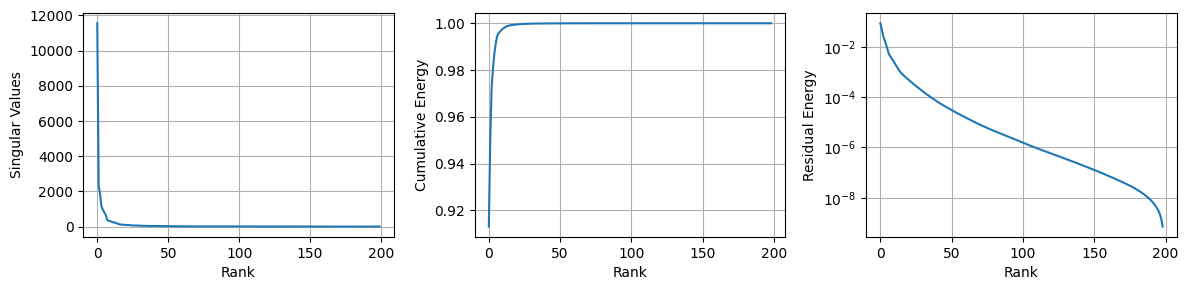

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3))

axs[0].plot(singular_values)
axs[0].set_ylabel("Singular Values")
axs[0].set_xlabel("Rank")

_energy = np.cumsum(singular_values**2)[:-1] / np.sum(singular_values**2)
axs[1].plot(_energy)
axs[1].set_ylabel("Cumulative Energy")
axs[1].set_xlabel("Rank")

axs[2].semilogy(1 - _energy)
axs[2].set_ylabel("Residual Energy")
axs[2].set_xlabel("Rank")

for ax in axs:
    ax.grid()
plt.tight_layout()

Let us select the rank to use

In [6]:
rank = 15

print(f"Selected rank: {rank}, which captures {100 * _energy[rank-1]:.2f}% of the energy.")

pod_coeffs = {
    key: (modes[:, :rank].T @ snapshots[key].reshape(-1, Nh).T) for key in snapshots.keys()
}

from sklearn.preprocessing import MinMaxScaler
pod_scaler = MinMaxScaler()
# fit on train only, then transform all splits
pod_scaled_coeffs = {}
pod_scaled_coeffs['train'] = pod_scaler.fit_transform(pod_coeffs['train'].T).reshape(Ns_sizes['train'], Nt_sizes['train'], rank)
for key in ['valid', 'test']:
    pod_scaled_coeffs[key] = pod_scaler.transform(pod_coeffs[key].T).reshape(Ns_sizes[key], Nt_sizes[key], rank)

Selected rank: 15, which captures 99.90% of the energy.


Let us plot the modes

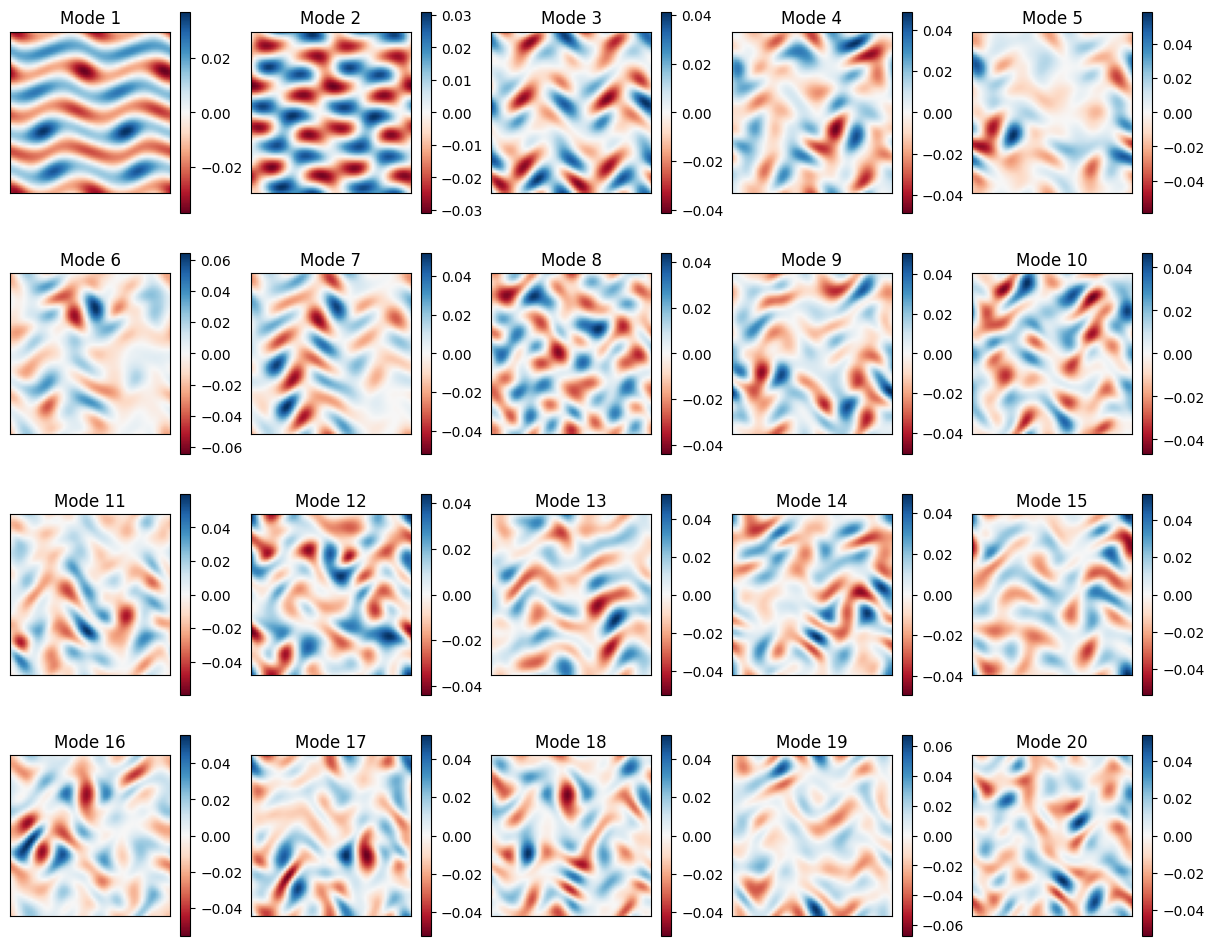

In [7]:
modes_to_plot = np.arange(0, 20)

nrows = 4
ncols = len(modes_to_plot) // nrows + (len(modes_to_plot) % nrows > 0)
fig, axs = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
axs = axs.flatten()

for i, mode_idx in enumerate(modes_to_plot):
    mode = modes[:, mode_idx].reshape((N, N))
    im = axs[i].imshow(
        mode, 
        extent=[0, L, 0, L], 
        origin='lower', 
        cmap='RdBu',
        vmin=-np.max(np.abs(mode)), vmax=np.max(np.abs(mode))
    )
    axs[i].set_title(f"Mode {mode_idx + 1}")
    axs[i].set_xticks([])
    axs[i].set_yticks([])

    fig.colorbar(im, ax=axs[i])

Let us select the sensors

In [8]:
np.random.seed(42)  # For reproducibility
num_sensors = 3
idx_sensors_locations = np.random.choice(Nh, size=num_sensors, replace=False)

measurements = {key: snapshots[key][:, :, idx_sensors_locations] for key in snapshots.keys()}

meas_scaler = MinMaxScaler()
# fit on train only, then transform all splits
measurements_scaled = {}
measurements_scaled['train'] = meas_scaler.fit_transform(measurements['train'].reshape(-1, num_sensors)).reshape(Ns_sizes['train'], Nt_sizes['train'], num_sensors)
for key in ['valid', 'test']:
    measurements_scaled[key] = meas_scaler.transform(measurements[key].reshape(-1, num_sensors)).reshape(Ns_sizes[key], Nt_sizes[key], num_sensors)

### Padding 
The measurements are either padded with zeros or with the first values of the measurements. The padding is necessary to ensure that the input to the model has a consistent shape, especially when dealing with time series data. In this case, we will pad the measurements with zeros.

In [9]:
import sys
sys.path.append('../')

from shred.processdata import Padding, TimeSeriesDataset, num2p, mre
import torch
from shred.models import SHRED, fit
import os

# GPU
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

lags = 50

data_in_zeropad = {key: Padding(
    torch.from_numpy(measurements_scaled[key]),
    lags,
    fill_value=False
).to(device) for key in measurements_scaled.keys()}

data_in_icpad = {key: Padding(
    torch.from_numpy(measurements_scaled[key]),
    lags,
    fill_value=True
).to(device) for key in measurements_scaled.keys()}

data_out = {key: Padding(
    torch.from_numpy(pod_scaled_coeffs[key]),
    1,
    fill_value=False
).squeeze(1).to(device) for key in pod_scaled_coeffs.keys()}

### Generate training validation and test datasets both for reconstruction of states

datasets_zeropad = {key: TimeSeriesDataset(data_in_zeropad[key], data_out[key]) for key in data_in_zeropad.keys()}
datasets_icpad = {key: TimeSeriesDataset(data_in_icpad[key], data_out[key]) for key in data_in_icpad.keys()}

output_size = rank

## Training the SHRED model

In this section, we will train the SHRED model using the prepared data. The model will be trained to reconstruct and predict the flow based on the low-dimensional representation obtained from the SVD. The training process involves optimizing the model parameters to minimize the reconstruction and prediction errors.

In [10]:
shred_zeropad = SHRED(num_sensors, output_size, hidden_size = 64, hidden_layers = 2, decoder_sizes = [350, 400], dropout = 0.1).to(device)
shred_icpad = SHRED(num_sensors, output_size, hidden_size = 64, hidden_layers = 2, decoder_sizes = [350, 400], dropout = 0.1).to(device)

fit_errs_zeropad = fit(shred_zeropad, datasets_zeropad['train'], datasets_zeropad['valid'],  batch_size = 64, epochs = 500, lr = 1e-3, verbose = True, patience = 30)
fit_errs_icpad = fit(shred_icpad, datasets_icpad['train'], datasets_icpad['valid'],  batch_size = 64, epochs = 500, lr = 1e-3, verbose = True, patience = 30)

Training done: Training loss = 1.35% 	 Validation loss = 1.71%      
Training done: Training loss = 1.24% 	 Validation loss = 1.80%      


Let us plot the losses over epochs for both the zero-padded and initial condition padded models. 

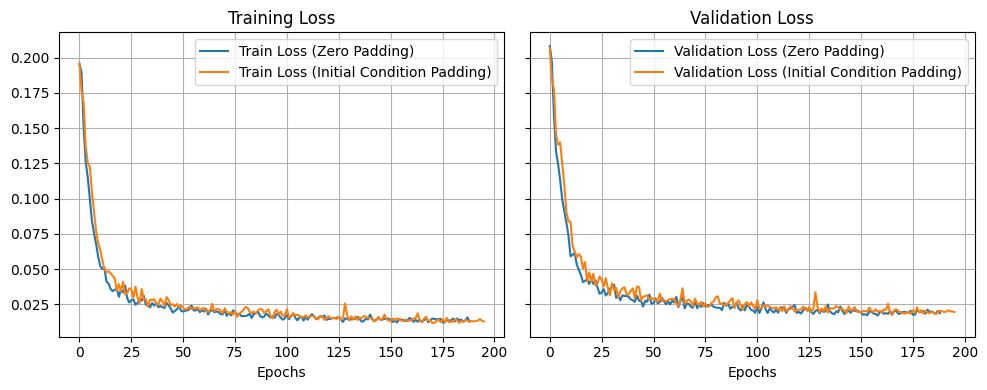

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
axs[0].plot(fit_errs_zeropad[0], label='Train Loss (Zero Padding)')
axs[0].plot(fit_errs_icpad[0], label='Train Loss (Initial Condition Padding)')
axs[0].set_title("Training Loss")

axs[1].plot(fit_errs_zeropad[1], label='Validation Loss (Zero Padding)')
axs[1].plot(fit_errs_icpad[1], label='Validation Loss (Initial Condition Padding)')
axs[1].set_title("Validation Loss")

for ax in axs:
    ax.set_xlabel("Epochs")
    ax.grid()
    ax.legend()

plt.tight_layout()

Let us evaluate the performance over the test and predict set for both the zero-padded and initial condition padded models.

In [12]:
test_pod_shred = {
    "zeropad": shred_zeropad(datasets_zeropad['test'].X.to(device)).detach(),
    "icpad": shred_icpad(datasets_icpad['test'].X.to(device)).detach()
}

out_data = datasets_zeropad['test'].Y.detach()

print("Test MRE (Zero Padding):", num2p(mre(out_data, test_pod_shred['zeropad'])))
print("Test MRE (IC Padding):", num2p(mre(out_data, test_pod_shred['icpad'])))

out_data = datasets_zeropad['test'].Y.detach().cpu().reshape(Ns_sizes['test'], Nt_sizes['test'], rank)
test_pod_shred = {
    "zeropad": shred_zeropad(datasets_zeropad['test'].X.to(device)).detach().cpu().reshape(Ns_sizes['test'], Nt_sizes['test'], rank),
    "icpad": shred_icpad(datasets_icpad['test'].X.to(device)).detach().cpu().reshape(Ns_sizes['test'], Nt_sizes['test'], rank)
}

Test MRE (Zero Padding): 2.22%
Test MRE (IC Padding): 2.27%


Let us make some plots of the reconstructed POD coeffs

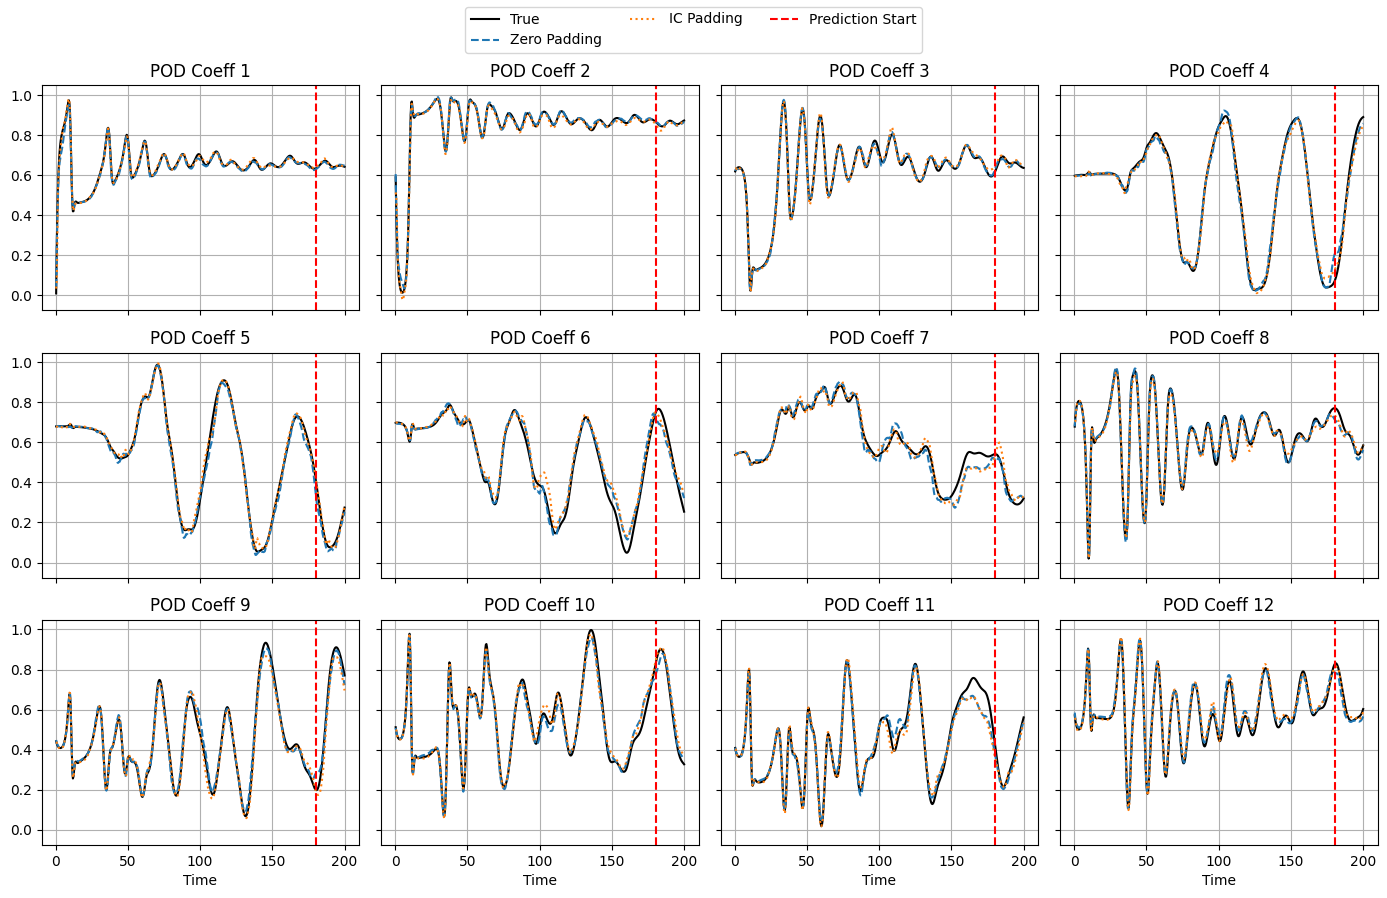

In [16]:
nrows = 3
ncols = 4

jj = 0

fig, axs = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3 * nrows), sharex=True, sharey=True)
axs = axs.flatten()

for i in range(len(axs)):
    ax = axs[i]

    ax.plot(times, out_data[jj, :, i], label='True', color='black')
    ax.plot(times, test_pod_shred['zeropad'][jj, :, i], label='Zero Padding', linestyle='--')
    ax.plot(times, test_pod_shred['icpad'][jj, :, i], label='IC Padding', linestyle=':')

    ax.set_title(f"POD Coeff {i+1}")
    if i > (nrows * ncols - ncols - 1):
        ax.set_xlabel("Time")
    ax.grid()
    ax.axvline(times[prediction_time_cut], color='red', linestyle='--', label='Prediction Start')

_lin, _lab = axs[0].get_legend_handles_labels()
fig.legend(_lin, _lab, loc='upper center', ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.95])

Let us reconstruct the flow field from the predicted POD coefficients and visualize the results. The reconstructed flow fields will be compared to the true flow fields to assess the accuracy of the predictions.

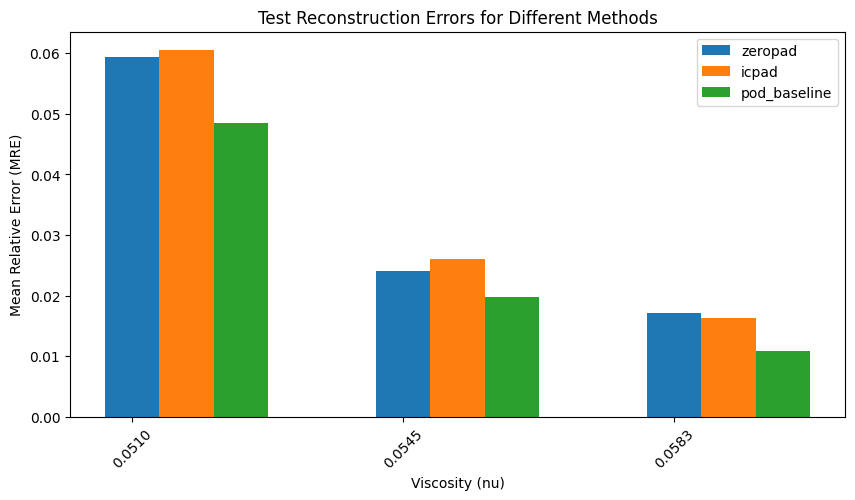

In [14]:
test_recon = {
    _kind: (modes[:, :rank] @ (
        pod_scaler.inverse_transform(test_pod_shred[_kind].reshape(-1, rank)).T
        )).T.reshape(Ns_sizes['test'], Nt_sizes['test'], Nh)
    for _kind in ['zeropad', 'icpad']
}
test_recon['pod_baseline'] = (modes[:, :rank] @ (modes[:, :rank].T @ snapshots['test'].reshape(-1, Nh).T)).T.reshape(Ns_sizes['test'], Nt_sizes['test'], Nh)

test_errors = {
    _kind: [np.mean(
        np.linalg.norm(snapshots['test'][test_indices] - test_recon[_kind][test_indices], axis=1) / np.linalg.norm(snapshots['test'][test_indices], axis=1)
    ) for test_indices in range(Ns_sizes['test'])]
    for _kind in test_recon.keys()
}

#Plotting the test errors for each method
plt.figure(figsize=(10, 5))
for _kind in test_errors.keys():
    plt.bar(np.arange(len(test_errors[_kind])) + 0.2 * list(test_errors.keys()).index(_kind), test_errors[_kind], width=0.2, label=_kind)
plt.xticks(np.arange(len(test_errors['zeropad'])), [f"{nu_values[test_idx[i]]:.4f}" for i in range(len(test_idx))], rotation=45)
plt.title("Test Reconstruction Errors for Different Methods")
plt.xlabel("Viscosity (nu)")
plt.ylabel("Mean Relative Error (MRE)")
plt.legend()

Let us make a video for the test set

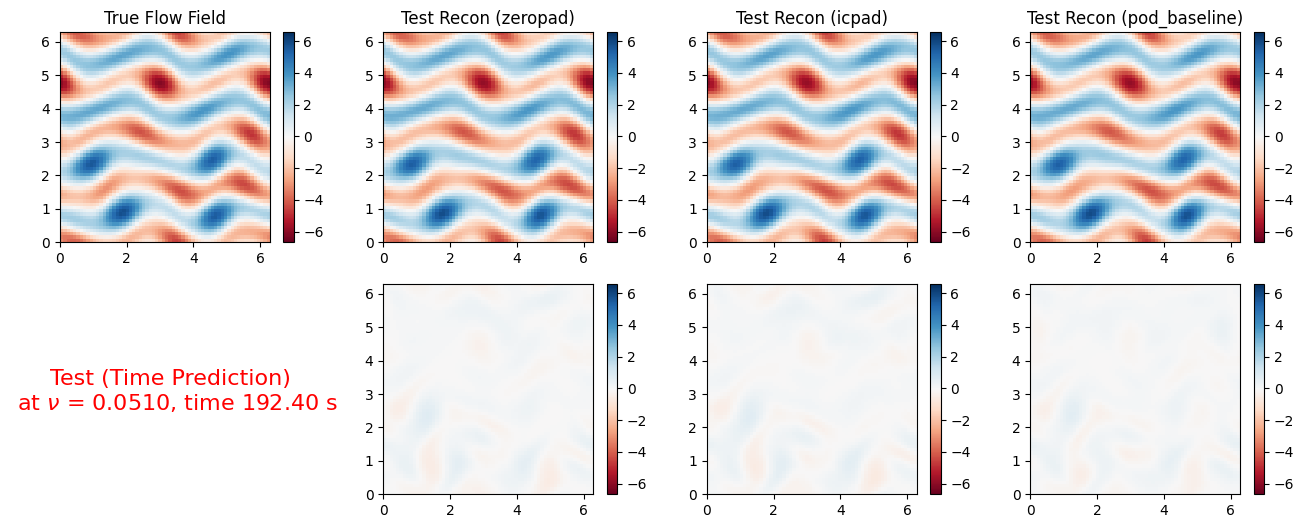

In [ ]:
nrows = 2
ncols = len(test_errors.keys()) + 1

test_idx_to_plot = 0  # Index of the test case to plot

for tt in range(0, Nt_sizes['test'], 20):
    fig, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))

    im = axs[0, 0].imshow(snapshots['test'][test_idx_to_plot, tt].reshape((N, N)), extent=[0, L, 0, L], origin='lower', cmap='RdBu', vmin=clims[0], vmax=clims[1])
    fig.colorbar(im, ax=axs[0, 0])
    axs[0, 0].set_title("True Flow Field")

    for i, _kind in enumerate(test_recon.keys()):
        im = axs[0, i+1].imshow(test_recon[_kind][test_idx_to_plot, tt].reshape((N, N)), extent=[0, L, 0, L], origin='lower', cmap='RdBu', vmin=clims[0], vmax=clims[1])
        axs[0, i+1].set_title(f"Test Recon ({_kind})")
        fig.colorbar(im, ax=axs[0, i+1])

        _res = snapshots['test'][test_idx_to_plot, tt] - test_recon[_kind][test_idx_to_plot, tt]
        im = axs[1, i+1].imshow(_res.reshape((N, N)), extent=[0, L, 0, L], origin='lower', cmap='RdBu', vmin=clims[0], vmax=clims[1])
        fig.colorbar(im, ax=axs[1, i+1])

    axs[1, 0].axis('off')

    if tt > prediction_time_cut:
        fig.text(0.2, 0.25, "Test (Time Prediction) \n"+ r" at $\nu$ = {:.4f}, time {:.2f} s".format(nu_values[test_idx[test_idx_to_plot]], times[tt]), ha='center', fontsize=16, color='red')
    else:
        fig.text(0.2, 0.25, r"Test at $\nu$ = {:.4f}".format(nu_values[test_idx[test_idx_to_plot]])+ "\n time {:.2f} s".format(times[tt]), ha='center', fontsize=16)

    for ax in axs.flatten():
        ax.set_xticks([])
        ax.set_yticks([])

    plt.show()
    clc(wait=True)
    plt.close()